In [ ]:
import os, sys
import time
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')

from plotly import __version__
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import cufflinks as cf
cf.go_offline()

from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,OneHotEncoder,StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_selection import RFE

from numpy import set_printoptions
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB



In [ ]:
exps_dir = "../../exps"
if os.path.exists(exps_dir) == False: # tạo thư mục (nếu chưa có)
  os.makedirs(exps_dir, exist_ok=True)

save_dir = f"{exps_dir}/feature1"
os.makedirs(save_dir, exist_ok=True)
test_size=0.33
seed=42

* kiểm tra và tạo các thư mục (nếu chưa có)
* tập test 33%

# 5. Xây dựng và đánh giá mô hình học sâu Neutual Network

In [ ]:
x_train=pd.read_excel(f'{save_dir}/x_train.xlsx')
y_train=pd.read_excel(f'{save_dir}/y_train.xlsx')
x_test=pd.read_excel(f'{save_dir}/x_test.xlsx')
y_test=pd.read_excel(f'{save_dir}/y_test.xlsx')
feature_model_selection=dict(np.load(f'{exps_dir}/feature1/feature_model_selection.npz',allow_pickle=True))['feature_model_selection']
feature_model_selection = {key: value for key, value in feature_model_selection.item().items()}
feature_model_selection

{'LR': ['skewness', 'variance'],
 'LDA': ['curtosis', 'skewness'],
 'DTC': ['skewness', 'variance'],
 'RD': ['skewness', 'variance'],
 'KNC': ['variance', 'skewness'],
 'GNB': ['variance', 'skewness'],
 'NN': ['variance', 'skewness'],
 'BG': ['variance', 'skewness'],
 'NB': ['variance', 'skewness'],
 'SVM': ['variance', 'skewness']}

* Sử dụng thư viện **imbalanced-learn** để thực hiện Oversampling bằng phương pháp **SMOTE (Synthetic Minority Over-sampling Technique).** 

#### Giải thích:
* Vì tập dữ liệu của nhóm là tập dữ liệu phân loại không cân bằng => **SMOTE** được sử dụng để tăng cường dữ liệu trong trường hợp mẫu của lớp thiểu số (minority class) quá ít so với lớp đa số (majority class), giúp cân bằng dữ liệu và cải thiện hiệu suất của mô hình.

In [ ]:
x_test.shape

(405, 4)

In [ ]:
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam

model = Sequential()
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Lớp thứ hai
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Lớp thứ ba
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Lớp thứ tư
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Lớp đầu ra với activation function 'sigmoid' cho bài toán phân lớp nhị phân
model.add(Dense(1, activation='sigmoid'))

model.summary()



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

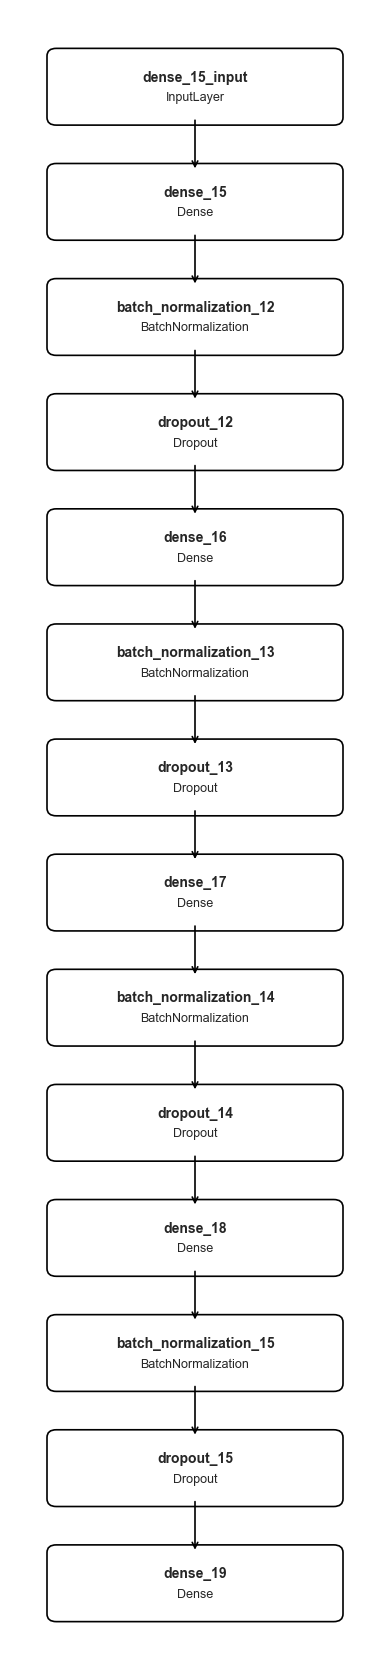

In [ ]:
import matplotlib.patches as patches

def plot_model(model, to_file='model.png', show_shapes=False, show_layer_names=True):
    layer_data = []
    
    # Lấy thông tin Input Layer
    first_layer_name = model.layers[0].name
    layer_data.append({
        "name": first_layer_name + '_input' if not first_layer_name.endswith('_input') else first_layer_name,
        "class": "InputLayer"
    })
    
    # Lấy thông tin các lớp bên trong
    for layer in model.layers:
        layer_data.append({
            "name": layer.name,
            "class": layer.__class__.__name__
        })
        
    # Bắt đầu vẽ đồ thị
    fig, ax = plt.subplots(figsize=(4, 1.2 * len(layer_data)))
    ax.axis('off') 
    
    box_width = 3.0  # Thu hẹp độ rộng hộp
    box_height = 0.8 # Thu hẹp độ cao hộp
    x_center = 0
    y_start = 0
    y_step = 1.5     # Khoảng cách giữa các hộp
    
    for i, data in enumerate(layer_data):
        y = y_start - i * y_step
        
        # Vẽ hộp (Chỉ là một hình chữ nhật bo góc đơn giản)
        rect = patches.FancyBboxPatch(
            (x_center - box_width/2, y - box_height/2), 
            box_width, box_height, 
            boxstyle="round,pad=0.1", 
            ec="black", fc="white", lw=1.2
        )
        ax.add_patch(rect)
        
        # Text hiển thị (Căn vào chính giữa hộp)
        ax.text(x_center, y + 0.12, data['name'], ha='center', va='center', fontweight='bold', fontsize=10)
        ax.text(x_center, y - 0.15, data['class'], ha='center', va='center', fontsize=9)
        
        # Vẽ mũi tên nối giữa các hộp
        if i > 0:
            prev_y = y_start - (i - 1) * y_step - box_height/2
            curr_y = y + box_height/2
            ax.annotate('', xy=(x_center, curr_y), xytext=(x_center, prev_y),
                        arrowprops=dict(arrowstyle='->', lw=1.2, color='black'))
            
    # Thiết lập giới hạn trục tọa độ
    plt.xlim(-2, 2)
    plt.ylim(y_start - (len(layer_data)-1) * y_step - 1, 1)
    plt.tight_layout()
    plt.savefig(to_file, dpi=300, bbox_inches='tight')
    plt.show()

# Gọi hàm để xuất ảnh
plot_model(model, to_file="model_simple.png")

### Giải thích:
   Nhóm sử dụng thư viện TensorFlow và Keras xây dựng một mô hình mạng nơ-ron sử dụng Sequential API:
   
   1. Đầu tiên, tạo mô hình Sử dụng mô hình tuần tự **Sequential**
   2. Sau đó, thêm các lớp Dense với hàm kích hoạt **'relu'**. Nhóm sử dụng **Dropout** tại mỗi tầng để ngẫu nhiên "tắt" khoảng 50% số nơ-ron tại tầng đó trong quá trình huấn luyện, ngăn chặn hiện tượng quá mức học (overfitting).
   3. Thêm lớp output với hàm kích hoạt 'tanh'. Hàm **'tanh'** chuyển đổi mỗi giá trị đầu ra từ khoảng (-∞, ∞) về khoảng (-1, 1).
   4. Compile mô hình: 
      * loss=**binary_crossentropy** được sử dụng vì đây là một bài toán phân loại nhị phân. 
      * optimizer=**adam** là một thuật toán tối ưu hóa phổ biến. 
      * metric=**'accuracy'**, Theo dõi độ chính xác của mô hình trong quá trình huấn luyện.

In [ ]:
import time
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from sklearn.metrics import confusion_matrix, classification_report

# 1. Cấu hình mô hình (Sửa lỗi 'lr' thành 'learning_rate')
lr = 0.0001
model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])

# 2. Định nghĩa Custom Callback (Sửa lỗi mảng dọc và lỗi ghi đè)
class ConfusionMatrixCallback(Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data
        self.relist = {} # Lưu dự đoán theo Epoch
        self.acc = []    # Lưu Accuracy theo Epoch

    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val = self.validation_data
        
        # Dự đoán và dùng .flatten() để biến [[0],[0]] thành [0, 0] nằm ngang
        y_pred = self.model.predict(X_val, verbose=0)
        y_pred_binary = (y_pred > 0.5).astype(int).flatten()

        # Tính toán Accuracy
        report_dict = classification_report(y_val, y_pred_binary, output_dict=True, zero_division=0)
        current_acc = report_dict['accuracy']
        
        # Lưu trữ dữ liệu (Dùng epoch + 1 làm Key để không bị ghi đè khi trùng Accuracy)
        self.acc.append(current_acc)
        self.relist[epoch + 1] = y_pred_binary

        # In kết quả nhanh mỗi Epoch để theo dõi
        print(f"\n>>> Epoch {epoch + 1} - Accuracy: {current_acc:.4f}")
        print(f"Ma trận nhầm lẫn:\n{confusion_matrix(y_val, y_pred_binary)}")

# 3. Khởi tạo các Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, verbose=1)
checkpointer = ModelCheckpoint(filepath="BankNote_Weights.keras", save_best_only=True, verbose=1)
confusion_matrix_callback = ConfusionMatrixCallback(validation_data=(x_test, y_test))

# 4. Huấn luyện (Đảm bảo có 'import time' ở đầu để không lỗi undefined)
start_time = time.time()

history = model.fit(
    x=x_train, 
    y=y_train,
    validation_data=(x_test, y_test),
    batch_size=64,
    epochs=120, 
    callbacks=[early_stopping, lr_scheduler, checkpointer, confusion_matrix_callback]
)

end_time = time.time()
print(f"\n--- Hoàn thành! Thời gian huấn luyện: {end_time - start_time:.2f} giây ---")

Epoch 1/120
12/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5918 - loss: 0.7833
Epoch 1: val_loss improved from None to 0.66610, saving model to BankNote_Weights.keras

Epoch 1: finished saving model to BankNote_Weights.keras

>>> Epoch 1 - Accuracy: 0.5654
Ma trận nhầm lẫn:
[[221   0]
 [176   8]]
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.7021 - loss: 0.6061 - val_accuracy: 0.5654 - val_loss: 0.6661 - learning_rate: 1.0000e-04
Epoch 2/120
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8555 - loss: 0.3127
Epoch 2: val_loss improved from 0.66610 to 0.64376, saving model to BankNote_Weights.keras

Epoch 2: finished saving model to BankNote_Weights.keras

>>> Epoch 2 - Accuracy: 0.5457
Ma trận nhầm lẫn:
[[221   0]
 [184   0]]
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8762 - loss: 0.2797 - val_accuracy: 0.5457 - val_loss: 0.6438 - learning_rate: 1.0000e-04
Epoch 3/120
12/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9413 - loss: 0.1831
Epoch 3: val_l

In [ ]:
# 1. In Accuracy
print(f"Accuracy qua {len(confusion_matrix_callback.acc)} epoch:")
print([round(a, 4) for a in confusion_matrix_callback.acc])

# 2. Lấy kết quả tốt nhất để làm báo cáo
best_idx = np.argmax(confusion_matrix_callback.acc)
print(f"\nĐộ chính xác cao nhất đạt được: {confusion_matrix_callback.acc[best_idx]:.4f} tại Epoch {best_idx + 1}")
print(f"\nMảng dự đoán của Epoch {best_idx + 1} (Dùng để tính Confusion Matrix):")
print(confusion_matrix_callback.relist[best_idx + 1])

Accuracy qua 43 epoch:
[0.5654, 0.5457, 0.5457, 0.5457, 0.5457, 0.5457, 0.5457, 0.5457, 0.5457, 0.5457, 0.5457, 0.5481, 0.5605, 0.6, 0.6568, 0.7309, 0.8, 0.8444, 0.8914, 0.9259, 0.9407, 0.963, 0.9827, 0.9877, 0.9926, 0.9926, 0.9975, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Độ chính xác cao nhất đạt được: 1.0000 tại Epoch 28

Mảng dự đoán của Epoch 28 (Dùng để tính Confusion Matrix):
[0 1 1 1 1 1 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 1 1 0 1 1 0 0 0 0
 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1
 0 1 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1
 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 0 1 1
 1 1 1 1 0 1 0 1 0 0 0 1 0 1 1 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 0 1 1 1 1 1 1
 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 1 1 1 0 0 0 0 1 1
 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1 1 1 1
 1 1 0 1 0 1 1 1 0 0 1 1 0 0 1 0 1 1 0 1 0 1 0 0 

In [ ]:
predictions=confusion_matrix_callback.relist[max(confusion_matrix_callback.acc)]
predictions
max(confusion_matrix_callback.acc)

1.0

In [ ]:
(classification_report(y_test,predictions)).split('\n')[5]

'    accuracy                           0.57       405'

In [ ]:
for epoch, acc in enumerate(history.history['val_accuracy']):
    print(f"Epoch {epoch + 1} - Validation Accuracy: {acc}")

Epoch 1 - Validation Accuracy: 0.565432071685791
Epoch 2 - Validation Accuracy: 0.5456790328025818
Epoch 3 - Validation Accuracy: 0.5456790328025818
Epoch 4 - Validation Accuracy: 0.5456790328025818
Epoch 5 - Validation Accuracy: 0.5456790328025818
Epoch 6 - Validation Accuracy: 0.5456790328025818
Epoch 7 - Validation Accuracy: 0.5456790328025818
Epoch 8 - Validation Accuracy: 0.5456790328025818
Epoch 9 - Validation Accuracy: 0.5456790328025818
Epoch 10 - Validation Accuracy: 0.5456790328025818
Epoch 11 - Validation Accuracy: 0.5456790328025818
Epoch 12 - Validation Accuracy: 0.5481481552124023
Epoch 13 - Validation Accuracy: 0.5604938268661499
Epoch 14 - Validation Accuracy: 0.6000000238418579
Epoch 15 - Validation Accuracy: 0.6567901372909546
Epoch 16 - Validation Accuracy: 0.7308642268180847
Epoch 17 - Validation Accuracy: 0.800000011920929
Epoch 18 - Validation Accuracy: 0.8444444537162781
Epoch 19 - Validation Accuracy: 0.8913580179214478
Epoch 20 - Validation Accuracy: 0.92592591

### Note:
   #### 1. Early Stopping:
   * **monitor='val_accuracy'**: Đây là đại lượng mà quá trình Early Stopping sẽ theo dõi. Trong trường hợp này, nó sẽ kiểm tra độ chính xác trên tập validation.
   * **min_delta=0.00005**: Số lượng thay đổi nhỏ nhất giữa hai epoch để coi là có sự cải thiện. Nếu không có sự cải thiện lớn hơn min_delta sau số lượng epoch 'patience', quá trình huấn luyện sẽ dừng lại.
   * **patience=11**: Số epoch mà mô hình có thể không cải thiện trước khi quá trình Early Stopping được kích hoạt.
   * **verbose=1**: Hiển thị thông báo khi quá trình Early Stopping được kích hoạt.
   * **restore_best_weights=True**: Khôi phục trọng số của mô hình tại epoch có độ chính xác cao nhất trên tập validation.
    
   #### 2. Learning Rate Scheduler (ReduceLROnPlateau):
   * **monitor='val_accuracy'**: Đại lượng mà Learning Rate Scheduler sẽ theo dõi, cũng là độ chính xác trên tập validation.
   * **factor=0.5**: Hệ số giảm learning rate. Khi được kích hoạt (sau 'patience' epochs mà không có cải thiện), learning rate sẽ được giảm đi một lượng bằng factor.
   * **patience=7**: Số epoch mà mô hình có thể không cải thiện trước khi learning rate được giảm.
   * **min_lr=0.00001**: Giới hạn dưới cho learning rate sau khi được giảm. Không bao giờ giảm dưới giá trị này.
   * **verbose=1**: Hiển thị thông báo khi quá trình giảm learning rate được kích hoạt.

### Giải thích:
   Nhóm thực hiện quá trình huấn luyện mô hình máy học với **model.fit**:
   
   * **x=x_train, y=y_train:** Dữ liệu đầu vào và nhãn cho quá trình đào tạo.
   * **validation_data=(x_test,y_test):** Dữ liệu kiểm tra.
   * **class_weight=feature_model_selection:** Trọng số lớp được áp dụng cho cân bằng lớp. (-> Vì tập dữ liệu mất cân bằng lớp)
   * Kích thước batch là **batch_size=128.** 
   * Số lượng epochs là **epochs=600.** 
   * Nhóm sử dụng **callbacks = [early_stopping,lr_scheduler]** để đảm bảo rằng mô hình được lưu lại tại những điểm có độ chính xác tốt nhất trên tập kiểm tra và đồng thời ngừng sớm nếu không có sự cải thiện đáng kể. Bên cạnh đó, giảm learning rate giúp mô hình hội tụ chậm hơn và tránh việc vượt qua điểm tối ưu toàn cục.